# exp-gs-002-13 — event-token TF-IDF: multinomial vs OVR LR

12번과 **완전히 같은 event-token TF-IDF 전처리**에서 다중 클래스 의사결정만 비교한다. 각 outer fold에서 fold-train 문서로만 vocabulary와 IDF를 fit하고, 같은 TF-IDF 행렬 위에 multinomial LR과 One-vs-Rest LR을 각각 학습한다.

비교: 08 primary / token multinomial / token OVR / primary+multinomial 0.5 / primary+OVR 0.5. OOF 단계에서는 `train.csv`만 읽으며, test를 읽거나 test 통계를 사용하지 않는다. WT·NaN은 mutation token을 만들지 않는다.

고정: `min_df=3`, unigram, `sublinear_tf=True`, LR `C=0.07`, `max_iter=2000`, `class_weight='balanced'`, Stratified 5-fold, seeds `42/2024/777`. 결과 이후에는 blend 비율·min_df·파라미터를 재탐색하지 않는다.

In [1]:
from pathlib import Path
import subprocess
import sys
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

def find_eda_dir():
    for path in (Path.cwd(), *Path.cwd().parents):
        direct = path / 'common' / 'exp-gs-002-memory-safe.py'
        project = path / 'experiments' / 'gs' / 'notebooks' / 'eda_pre_002' / 'common' / 'exp-gs-002-memory-safe.py'
        if direct.exists():
            return path
        if project.exists():
            return project.parent.parent
    raise FileNotFoundError('eda_pre_002 실행기를 찾지 못했습니다.')

EDA_DIR = find_eda_dir()
RUNNER = EDA_DIR / 'common' / 'exp-gs-002-memory-safe.py'
RESULT_DIR = EDA_DIR / 'result'
RESULT_DIR.mkdir(exist_ok=True)
RUN_ID = 'exp-gs-002-13'
CANDIDATE = 'H-AS-LR-exact-confusion-pairs-Apair-log1p'
SEEDS = (42, 2024, 777)
MIN_DF = 3
RUN_EXPERIMENT = True
OOF_TRAIN_ONLY = True
print({'runner': RUNNER, 'seeds': SEEDS, 'min_df': MIN_DF, 'oof_train_only': OOF_TRAIN_ONLY})

{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/eda_pre_002/common/exp-gs-002-memory-safe.py'), 'seeds': (42, 2024, 777), 'min_df': 3, 'oof_train_only': True}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if RUN_EXPERIMENT:
    for seed in tqdm(SEEDS, desc='13 | TF-IDF multinomial vs OVR | OOF', unit='seed'):
        subprocess.run([
            sys.executable, str(RUNNER),
            '--run-id', RUN_ID,
            '--candidate', CANDIDATE,
            '--seed', str(seed),
            '--event-tfidf-ovr',
            '--tfidf-min-df', str(MIN_DF),
        ], check=True)
else:
    print('RUN_EXPERIMENT=False: 결과 집계만 수행합니다.')

row-local mutation cache: 100%|██████████| 4384/4384 [00:10<00:00, 402.54it/s]
H-AS-LR-exact-confusion-pairs-Apair-log1p | TF-IDF multinomial vs OVR | seed 42: 100%|██████████| 5/5 [03:26<00:00, 41.29s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Apair-log1p",
  "model": "logistic",
  "seed": 42,
  "tfidf_min_df": 3,
  "tfidf_sublinear_tf": true,
  "primary_oof_macro_f1": 0.47814168846488037,
  "event_tfidf_multinomial_oof_macro_f1": 0.3782884640237529,
  "event_tfidf_ovr_oof_macro_f1": 0.47614610334900986,
  "blend_multinomial_0p5_oof_macro_f1": 0.4794557135599829,
  "blend_ovr_0p5_oof_macro_f1": 0.4834703526083619,
  "delta_ovr_blend_vs_multinomial_blend": 0.0040146390483790095,
  "primary_oof_accuracy": 0.45879696823093047,
  "event_tfidf_multinomial_oof_accuracy": 0.3971940009675859,
  "event_tfidf_ovr_oof_accuracy": 0.4578293823576842,
  "blend_multinomial_0p5_oof_accuracy": 0.45992581841638447,
  "blend_ovr_0p5_oof_accuracy": 0.46234478309950006,
  "token_prediction_disagreement_rate": 0.4076761812610869,
  "feature_count_mean": 8175.2,
  "tfidf_vocabulary_size_mean": 5875.8,
  "runtime_seconds": 206.75746925000567,
  "primary_convergence_warning_count": 0,
  "tfidf_mult

row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 392.94it/s]0s/seed]
H-AS-LR-exact-confusion-pairs-Apair-log1p | TF-IDF multinomial vs OVR | seed 2024: 100%|██████████| 5/5 [03:21<00:00, 40.38s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Apair-log1p",
  "model": "logistic",
  "seed": 2024,
  "tfidf_min_df": 3,
  "tfidf_sublinear_tf": true,
  "primary_oof_macro_f1": 0.4762175133106753,
  "event_tfidf_multinomial_oof_macro_f1": 0.37834570023612246,
  "event_tfidf_ovr_oof_macro_f1": 0.48209401153092346,
  "blend_multinomial_0p5_oof_macro_f1": 0.4770919206532897,
  "blend_ovr_0p5_oof_macro_f1": 0.4803383399998615,
  "delta_ovr_blend_vs_multinomial_blend": 0.0032464193465717717,
  "primary_oof_accuracy": 0.4594420254797613,
  "event_tfidf_multinomial_oof_accuracy": 0.397677793904209,
  "event_tfidf_ovr_oof_accuracy": 0.46040961135300756,
  "blend_multinomial_0p5_oof_accuracy": 0.4591194968553459,
  "blend_ovr_0p5_oof_accuracy": 0.46169972585066926,
  "token_prediction_disagreement_rate": 0.4123528463151105,
  "feature_count_mean": 8175.0,
  "tfidf_vocabulary_size_mean": 5868.4,
  "runtime_seconds": 202.18433079200622,
  "primary_convergence_warning_count": 0,
  "tfidf_mult

row-local mutation cache: 100%|██████████| 4384/4384 [00:10<00:00, 400.28it/s]6s/seed]
H-AS-LR-exact-confusion-pairs-Apair-log1p | TF-IDF multinomial vs OVR | seed 777: 100%|██████████| 5/5 [03:11<00:00, 38.23s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Apair-log1p",
  "model": "logistic",
  "seed": 777,
  "tfidf_min_df": 3,
  "tfidf_sublinear_tf": true,
  "primary_oof_macro_f1": 0.481145738774279,
  "event_tfidf_multinomial_oof_macro_f1": 0.3705716160280971,
  "event_tfidf_ovr_oof_macro_f1": 0.4735678213237862,
  "blend_multinomial_0p5_oof_macro_f1": 0.48436600336351787,
  "blend_ovr_0p5_oof_macro_f1": 0.4855817039961349,
  "delta_ovr_blend_vs_multinomial_blend": 0.0012157006326170006,
  "primary_oof_accuracy": 0.4613771972262538,
  "event_tfidf_multinomial_oof_accuracy": 0.39138848572810836,
  "event_tfidf_ovr_oof_accuracy": 0.4565392678600226,
  "blend_multinomial_0p5_oof_accuracy": 0.46411869053378485,
  "blend_ovr_0p5_oof_accuracy": 0.4628285760361232,
  "token_prediction_disagreement_rate": 0.41138526044186424,
  "feature_count_mean": 8170.4,
  "tfidf_vocabulary_size_mean": 5869.6,
  "runtime_seconds": 191.50516212500224,
  "primary_convergence_warning_count": 0,
  "tfidf_multi

13 | TF-IDF multinomial vs OVR | OOF: 100%|██████████| 3/3 [11:11<00:00, 223.98s/seed]


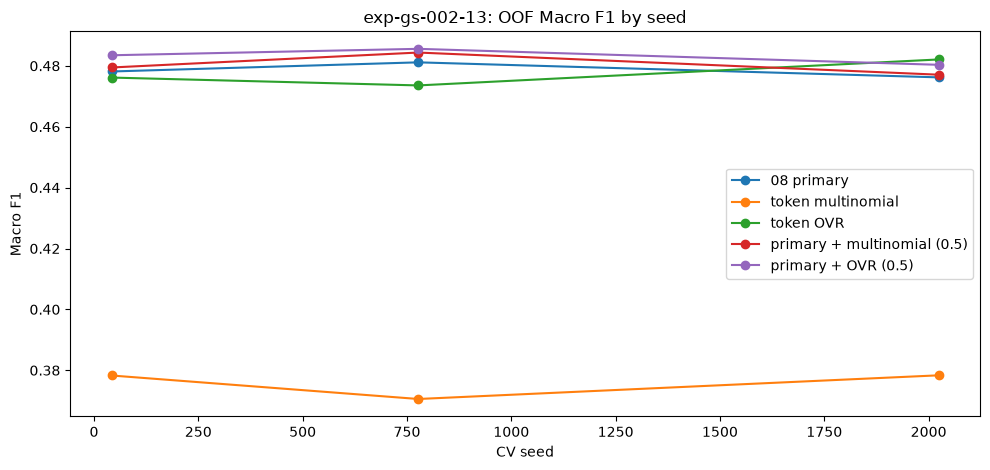

12번 기존 고정 0.5 앙상블 비교 기준


,experiment_id,seed_count,min_df,primary_macro_f1_mean,event_tfidf_macro_f1_mean,blend_0p5_macro_f1_mean,blend_delta_mean,blend_delta_std,all_seed_blend_delta_positive,tfidf_vocab_size_mean,feature_count_mean,convergence_warning_count,leakage_check,nan_as_mutation_count
0,exp-gs-002-12,3,3,0.478502,0.375735,0.480305,0.001803,0.001247,True,5871.266667,8173.533333,0,True,0


,experiment_id,model,seed,tfidf_min_df,tfidf_sublinear_tf,primary_oof_macro_f1,event_tfidf_multinomial_oof_macro_f1,event_tfidf_ovr_oof_macro_f1,blend_multinomial_0p5_oof_macro_f1,blend_ovr_0p5_oof_macro_f1,...,token_prediction_disagreement_rate,feature_count_mean,tfidf_vocabulary_size_mean,runtime_seconds,primary_convergence_warning_count,tfidf_multinomial_convergence_warning_count,tfidf_ovr_convergence_warning_count,convergence_warning_count,leakage_check,nan_as_mutation_count
0,H-AS-LR-exact-confusion-pairs-Apair-log1p,logistic,42,3,True,0.478142,0.378288,0.476146,0.479456,0.483470,...,0.407676,8175.2,5875.8,206.757469,0,0,0,0,True,0
2,H-AS-LR-exact-confusion-pairs-Apair-log1p,logistic,777,3,True,0.481146,0.370572,0.473568,0.484366,0.485582,...,0.411385,8170.4,5869.6,191.505162,0,0,0,0,True,0
1,H-AS-LR-exact-confusion-pairs-Apair-log1p,logistic,2024,3,True,0.476218,0.378346,0.482094,0.477092,0.480338,...,0.412353,8175.0,5868.4,202.184331,0,0,0,0,True,0


,experiment_id,seed_count,min_df,primary_oof_macro_f1_mean,event_tfidf_multinomial_oof_macro_f1_mean,event_tfidf_ovr_oof_macro_f1_mean,blend_multinomial_0p5_oof_macro_f1_mean,blend_ovr_0p5_oof_macro_f1_mean,primary_oof_macro_f1_std,event_tfidf_multinomial_oof_macro_f1_std,...,blend_ovr_0p5_oof_macro_f1_std,ovr_blend_delta_vs_multinomial_blend_mean,ovr_blend_delta_vs_multinomial_blend_std,all_seed_ovr_blend_delta_positive,token_prediction_disagreement_rate_mean,tfidf_vocabulary_size_mean,feature_count_mean,convergence_warning_count,leakage_check,nan_as_mutation_count
0,exp-gs-002-13,3,3,0.478502,0.375735,0.477269,0.480305,0.48313,0.002484,0.004472,...,0.002638,0.002826,0.001446,True,0.410471,5871.266667,8173.533333,0,True,0


In [3]:
def result_path(seed, suffix):
    return RESULT_DIR / f'{RUN_ID}_{CANDIDATE}_event-tfidf-ovr_seed{seed}_{suffix}.csv'

oof_files = [result_path(seed, 'oof') for seed in SEEDS]
missing = [path for path in oof_files if not path.exists()]
if missing:
    raise FileNotFoundError('누락 결과 파일:\n' + '\n'.join(map(str, missing)))

per_seed = pd.concat([pd.read_csv(path) for path in oof_files], ignore_index=True).sort_values('seed')
assert per_seed['leakage_check'].all()
assert per_seed['nan_as_mutation_count'].eq(0).all()
assert per_seed['tfidf_min_df'].eq(MIN_DF).all()

metric_columns = [
    'primary_oof_macro_f1',
    'event_tfidf_multinomial_oof_macro_f1',
    'event_tfidf_ovr_oof_macro_f1',
    'blend_multinomial_0p5_oof_macro_f1',
    'blend_ovr_0p5_oof_macro_f1',
]
summary = pd.DataFrame([{
    'experiment_id': RUN_ID,
    'seed_count': len(SEEDS),
    'min_df': MIN_DF,
    **{f'{column}_mean': per_seed[column].mean() for column in metric_columns},
    **{f'{column}_std': per_seed[column].std() for column in metric_columns},
    'ovr_blend_delta_vs_multinomial_blend_mean': per_seed['delta_ovr_blend_vs_multinomial_blend'].mean(),
    'ovr_blend_delta_vs_multinomial_blend_std': per_seed['delta_ovr_blend_vs_multinomial_blend'].std(),
    'all_seed_ovr_blend_delta_positive': bool(per_seed['delta_ovr_blend_vs_multinomial_blend'].gt(0).all()),
    'token_prediction_disagreement_rate_mean': per_seed['token_prediction_disagreement_rate'].mean(),
    'tfidf_vocabulary_size_mean': per_seed['tfidf_vocabulary_size_mean'].mean(),
    'feature_count_mean': per_seed['feature_count_mean'].mean(),
    'convergence_warning_count': int(per_seed['convergence_warning_count'].sum()),
    'leakage_check': bool(per_seed['leakage_check'].all()),
    'nan_as_mutation_count': int(per_seed['nan_as_mutation_count'].sum()),
}])

class_seed = pd.concat([pd.read_csv(result_path(seed, 'class_f1')).assign(seed=seed) for seed in SEEDS], ignore_index=True)
class_summary = class_seed.groupby(['variant', 'class'], as_index=False).agg(
    class_f1_mean=('f1-score', 'mean'),
    class_f1_std=('f1-score', 'std'),
    support=('support', 'first'),
)

per_seed.to_csv(RESULT_DIR / 'exp-gs-002-13_per_seed.csv', index=False)
summary.to_csv(RESULT_DIR / 'exp-gs-002-13_summary.csv', index=False)
class_summary.to_csv(RESULT_DIR / 'exp-gs-002-13_class_f1_summary.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 4.8))
labels = {
    'primary_oof_macro_f1': '08 primary',
    'event_tfidf_multinomial_oof_macro_f1': 'token multinomial',
    'event_tfidf_ovr_oof_macro_f1': 'token OVR',
    'blend_multinomial_0p5_oof_macro_f1': 'primary + multinomial (0.5)',
    'blend_ovr_0p5_oof_macro_f1': 'primary + OVR (0.5)',
}
for column, label in labels.items():
    ax.plot(per_seed['seed'], per_seed[column], marker='o', label=label)
ax.set(title='exp-gs-002-13: OOF Macro F1 by seed', xlabel='CV seed', ylabel='Macro F1')
ax.legend(loc='best')
fig.tight_layout()
fig.savefig(RESULT_DIR / 'exp-gs-002-13_oof_macro_f1.png', dpi=160, bbox_inches='tight')
plt.show()

comparison_12 = RESULT_DIR / 'exp-gs-002-12_summary.csv'
if comparison_12.exists():
    print('12번 기존 고정 0.5 앙상블 비교 기준')
    display(pd.read_csv(comparison_12))
display(per_seed)
display(summary)